# Import Libraries

In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from PIL import Image, ImageDraw, ImageFont
import math
import pandas as pd
from pathlib import Path
from tqdm import tqdm

In [2]:
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)

# Explore MHD Metadata

## MHD Metada Extraction

In [3]:
def extract_lndb_metadata(dataset_dir):
    """
    Extract metadata from every LNDb .mhd volume.
    """

    dataset_dir = Path(dataset_dir)

    records = []

    mhd_files = sorted(dataset_dir.glob("*.mhd"))

    for mhd_path in tqdm(
        mhd_files,
        desc="Extracting LNDb metadata",
        unit="scan"
    ):
        image = sitk.ReadImage(str(mhd_path))

        volume = sitk.GetArrayFromImage(image).astype(np.float32)
        # shape = (z, y, x)

        spacing = image.GetSpacing()
        # (x, y, z)

        size = image.GetSize()
        # (x, y, z)

        pixel_spacing_x = spacing[0]
        pixel_spacing_y = spacing[1]
        slice_spacing = spacing[2]

        rows = size[1]
        columns = size[0]
        num_slices = size[2]

        scan_length = num_slices * slice_spacing

        record = {
            # Scan information
            "lndbid": int(mhd_path.stem.replace("LNDb-", "")),
            "rows": rows,
            "columns": columns,
            "num_slices": num_slices,

            # Spatial resolution
            "pixel_spacing_x_mm": pixel_spacing_x,
            "pixel_spacing_y_mm": pixel_spacing_y,
            "slice_thickness_mm": slice_spacing,
            "slice_spacing_mm": slice_spacing,
            "scan_length_mm": scan_length,

            # HU scaling
            "rescale_slope": 1.0,
            "rescale_intercept": 0.0,

            # HU statistics
            "hu_min": float(volume.min()),
            "hu_max": float(volume.max()),
            "hu_mean": float(volume.mean()),
            "hu_std": float(volume.std()),
            "hu_p1": float(np.percentile(volume, 1)),
            "hu_p5": float(np.percentile(volume, 5)),
            "hu_p95": float(np.percentile(volume, 95)),
            "hu_p99": float(np.percentile(volume, 99)),
        }

        records.append(record)

    return pd.DataFrame(records)

In [4]:
# dataset_dir = Path("../../dataset/lndb/data")

# metadata_df = extract_lndb_metadata(dataset_dir)
# metadata_df.to_csv(
#     "../../dataset/_lndb/000_metadata/mhd_metadat.csv",
#     index=False
# )

## Load Metadata

In [5]:
mhd_metadata_df = pd.read_csv("../../dataset/_lndb/000_metadata/mhd_metadat.csv", index_col=False)

print(f"{'='*20} DataFrame Information {'='*20}")
mhd_metadata_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(mhd_metadata_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lndbid              236 non-null    int64  
 1   rows                236 non-null    int64  
 2   columns             236 non-null    int64  
 3   num_slices          236 non-null    int64  
 4   pixel_spacing_x_mm  236 non-null    float64
 5   pixel_spacing_y_mm  236 non-null    float64
 6   slice_thickness_mm  236 non-null    float64
 7   slice_spacing_mm    236 non-null    float64
 8   scan_length_mm      236 non-null    float64
 9   rescale_slope       236 non-null    float64
 10  rescale_intercept   236 non-null    float64
 11  hu_min              236 non-null    float64
 12  hu_max              236 non-null    float64
 13  hu_mean             236 non-null    float64
 14  hu_std              236 non-null    float6

,lndbid,rows,columns,num_slices,pixel_spacing_x_mm,pixel_spacing_y_mm,slice_thickness_mm,slice_spacing_mm,scan_length_mm,rescale_slope,rescale_intercept,hu_min,hu_max,hu_mean,hu_std,hu_p1,hu_p5,hu_p95,hu_p99
0,1,512,512,328,0.607422,0.607422,1.0,1.0,328.0,1.0,0.0,-1024.0,3071.0,-578.541565,495.969849,-1024.0,-1024.0,150.0,632.0
1,2,512,512,263,0.724609,0.724609,1.0,1.0,263.0,1.0,0.0,-1024.0,3071.0,-491.219879,473.682190,-1024.0,-1024.0,129.0,345.0
2,3,512,512,301,0.746094,0.746094,1.0,1.0,301.0,1.0,0.0,-1024.0,3071.0,-430.205841,485.412964,-1024.0,-1024.0,206.0,487.0
3,4,512,512,322,0.712891,0.712891,1.0,1.0,322.0,1.0,0.0,-1024.0,3071.0,-533.051208,486.216736,-1024.0,-1024.0,163.0,425.0
4,5,512,512,334,0.697266,0.697266,1.0,1.0,334.0,1.0,0.0,-1024.0,3071.0,-531.027161,482.558868,-1024.0,-1024.0,153.0,400.0


In [6]:
n_unique_lndbid = mhd_metadata_df["lndbid"].nunique()
print(f"Num of Unique LNDbId: {n_unique_lndbid}")

Num of Unique LNDbId: 236


## Descriptive Statistics

In [7]:
mhd_metadata_df.describe()

,lndbid,rows,columns,num_slices,pixel_spacing_x_mm,pixel_spacing_y_mm,slice_thickness_mm,slice_spacing_mm,scan_length_mm,rescale_slope,rescale_intercept,hu_min,hu_max,hu_mean,hu_std,hu_p1,hu_p5,hu_p95,hu_p99
count,236.000000,236.0,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.0,236.0,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000
mean,153.533898,512.0,561.627119,320.533898,0.632529,0.632546,0.996643,0.996643,318.570976,1.0,0.0,-4401.690678,5520.940678,-704.572807,1122.102979,-4005.084746,-2973.355932,156.720339,481.915254
std,89.470516,0.0,69.681561,37.307619,0.086062,0.086068,0.049565,0.049565,31.363412,0.0,0.0,4297.736957,6855.670411,334.139552,831.014793,3535.958432,3190.181761,28.517523,97.902303
min,1.000000,512.0,512.000000,251.000000,0.432789,0.432789,0.500000,0.500000,251.000000,1.0,0.0,-32714.000000,1926.000000,-2135.141602,428.353394,-8192.000000,-8192.000000,66.000000,215.000000
25%,79.750000,512.0,512.000000,298.750000,0.573660,0.573603,1.000000,1.000000,298.000000,1.0,0.0,-8192.000000,2604.500000,-822.231308,481.861710,-8192.000000,-8192.000000,137.750000,410.000000
50%,145.000000,512.0,512.000000,317.500000,0.643555,0.643555,1.000000,1.000000,317.000000,1.0,0.0,-1024.000000,3071.000000,-566.299042,498.251770,-1024.000000,-1024.000000,154.000000,468.000000
75%,232.500000,512.0,619.000000,340.000000,0.695801,0.695801,1.000000,1.000000,339.171679,1.0,0.0,-1024.000000,3071.000000,-490.825676,1827.457855,-1024.000000,-1024.000000,171.000000,537.250000
max,312.000000,512.0,804.000000,631.000000,0.894531,0.894531,1.400000,1.400000,481.600000,1.0,0.0,-1024.000000,32694.000000,-292.177826,3396.993164,-1018.000000,-1004.000000,294.000000,857.000000


- Image Size Consistency
    
    All LNDb CT scans have a consistent image height of 512 pixels, while the image width varies from 512 to 804 pixels. Unlike LIDC-IDRI, which uses a fixed image size of 512 × 512 pixels, LNDb includes scans with different reconstruction widths. Therefore, image resizing or cropping may be required if the segmentation or classification model expects a fixed input size.

- Number of Slices

    The number of slices ranges from 251 to 631, with a mean of approximately 321 slices. Although there is variability among scans, the overall scan length remains relatively consistent because the slice spacing is nearly uniform. Similar to LIDC-IDRI, this variation has little impact on a slice-based 2D segmentation or classification pipeline.
- Pixel Spacing Variation

    The in-plane pixel spacing varies between approximately 0.43 mm and 0.89 mm, indicating differences in spatial resolution across CT scans. As in LIDC-IDRI, this variability supports the application of image resampling to ensure consistent physical pixel dimensions before model training.
- Slice Thickness and Slice Spacing

    Slice thickness and slice spacing are nearly identical, ranging from 0.5 mm to 1.4 mm, with most scans having 1.0 mm spacing. Compared with LIDC-IDRI, LNDb exhibits much lower variability in slice spacing, resulting in more consistent voxel dimensions. Nevertheless, resampling to a standardized voxel spacing is still recommended for reproducible preprocessing.
- Scan Length

    The scan length ranges from 251 mm to 482 mm, with a mean of approximately 319 mm. This variation reflects differences in anatomical coverage between CT scans but does not directly affect the preprocessing pipeline for slice-based analysis.
- Rescale Parameters

    The rescale slope is consistently equal to 1, while the rescale intercept is consistently 0 for all scans. This indicates that the distributed LNDb MHD volumes have already been converted from the original DICOM representation, and voxel intensities can be used directly without additional HU conversion.
- Hounsfield Unit (HU) Distribution

    The HU statistics exhibit noticeable variability across scans, particularly in the minimum intensity and lower percentile values. Many scans contain a minimum intensity of −8192 HU, which is substantially below the physical HU range and likely represents background or padding values introduced during volume conversion. Consequently, HU clipping (e.g., [-1000, 400] HU) is recommended before intensity normalization to remove non-physical values and improve consistency across scans.

## EDA Dashboard

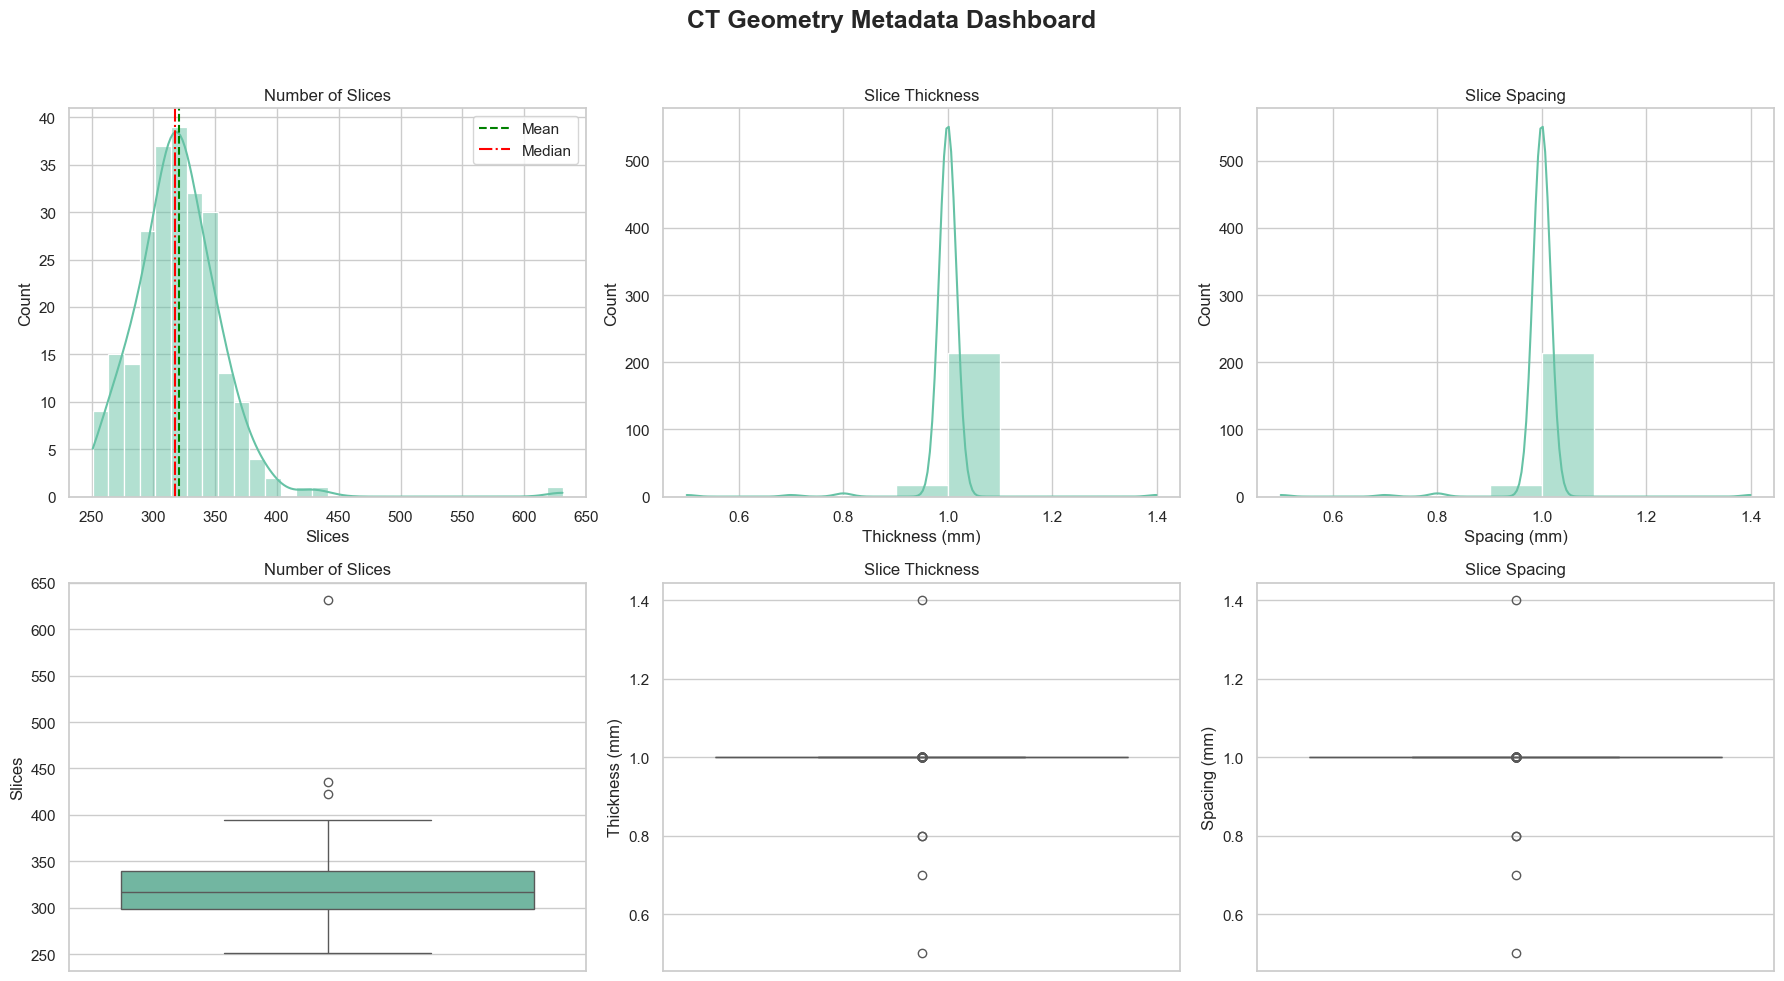

In [8]:
# Dashboard Layout
n_charts = 6
n_cols = 3
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows)
)

fig.suptitle(
    "CT Geometry Metadata Dashboard",
    fontsize=18,
    fontweight="bold"
)

axes = axes.flatten()

# Number of Slices Distribution
sns.histplot(
    mhd_metadata_df["num_slices"],
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].axvline(
    mhd_metadata_df["num_slices"].mean(),
    color="green",
    linestyle="--",
    label="Mean"
)

axes[0].axvline(
    mhd_metadata_df["num_slices"].median(),
    color="red",
    linestyle="-.",
    label="Median"
)

axes[0].set_title("Number of Slices")
axes[0].set_xlabel("Slices")
axes[0].set_ylabel("Count")
axes[0].legend()

# Slice Thickness Distribution
sns.histplot(
    mhd_metadata_df["slice_thickness_mm"],
    bins="auto",
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Slice Thickness")
axes[1].set_xlabel("Thickness (mm)")
axes[1].set_ylabel("Count")

# Slice Spacing Distribution
sns.histplot(
    mhd_metadata_df["slice_spacing_mm"],
    bins="auto",
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Slice Spacing")
axes[2].set_xlabel("Spacing (mm)")
axes[2].set_ylabel("Count")

# Boxplot: Number of Slices
sns.boxplot(
    y=mhd_metadata_df["num_slices"],
    ax=axes[3]
)

axes[3].set_title("Number of Slices")
axes[3].set_ylabel("Slices")

# Boxplot: Slice Thickness
sns.boxplot(
    y=mhd_metadata_df["slice_thickness_mm"],
    ax=axes[4]
)

axes[4].set_title("Slice Thickness")
axes[4].set_ylabel("Thickness (mm)")

# Boxplot: Slice Spacing
sns.boxplot(
    y=mhd_metadata_df["slice_spacing_mm"],
    ax=axes[5]
)

axes[5].set_title("Slice Spacing")
axes[5].set_ylabel("Spacing (mm)")

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## EDA Dashboard

# Explore trainNodules_gt (CSV)

## Load trainNodules_gt.csv

In [9]:
train_nodules_gt_df = pd.read_csv("../../dataset/_lndb/000_metadata/trainset_csv/trainNodules_gt.csv")

train_nodules_gt_df.columns = (
    train_nodules_gt_df.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(f"{'='*20} DataFrame Information {'='*20}")
train_nodules_gt_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(train_nodules_gt_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lndbid        1219 non-null   int64  
 1   radid         1219 non-null   object 
 2   radfindingid  1219 non-null   object 
 3   findingid     1219 non-null   int64  
 4   x             1219 non-null   float64
 5   y             1219 non-null   float64
 6   z             1219 non-null   float64
 7   agrlevel      1219 non-null   int64  
 8   nodule        1219 non-null   int64  
 9   volume        1219 non-null   float64
 10  text          1219 non-null   float64
dtypes: float64(5), int64(4), object(2)
memory usage: 104.9+ KB

==================== First 5 Rows Of A DataFrame ====================


,lndbid,radid,radfindingid,findingid,x,y,z,agrlevel,nodule,volume,text
0,1,"1,2,3","1,1,1",1,-44.203451,-119.073242,-37.5,3,1,222.360697,5.0
1,1,1,2,2,25.852539,-126.969727,-45.5,1,1,152.381031,4.0
2,2,"1,2,3","1,1,3",1,88.895508,-123.867513,-129.5,3,1,378.042297,5.0
3,2,"1,3","2,2",2,63.534180,-112.756836,-117.5,2,1,174.844563,5.0
4,2,"1,3","3,5",3,-103.850586,-116.742188,-253.0,2,1,297.708309,5.0


In [10]:
n_unique_lndbid = train_nodules_gt_df["lndbid"].nunique()
print(f"Num of Unique LNDbId: {n_unique_lndbid}")

Num of Unique LNDbId: 229


## Enrichment

### Load allNods.csv

In [11]:
all_nodes_df = pd.read_csv("../../dataset/_lndb/000_metadata/allNods.csv")

all_nodes_df.columns = (
    all_nodes_df.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(f"{'='*20} DataFrame Information {'='*20}")
all_nodes_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(all_nodes_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lndbid             1234 non-null   int64  
 1   radid              1152 non-null   object 
 2   radfinding         1152 non-null   object 
 3   findingid          1234 non-null   int64  
 4   nodule             1152 non-null   object 
 5   x                  1152 non-null   float64
 6   y                  1152 non-null   float64
 7   z                  1152 non-null   float64
 8   diameq_rad         1234 non-null   float64
 9   texture            893 non-null    float64
 10  calcification      776 non-null    float64
 11  internalstructure  768 non-null    float64
 12  lobulation         768 non-null    float64
 13  malignancy         768 non-null    float64
 14  margin             772 non-null    float64
 15  spherici

,lndbid,radid,radfinding,findingid,nodule,x,y,z,diameq_rad,texture,...,spiculation,subtlety,lobe,textinstanceid,textquestion,pos_text,diam_text,nodtype,caract_text,where
0,1,"1,2,3","1,1,1",1,"1,1,1",-44.203451,-119.073242,-37.5,7.516572,5.0,...,2.333333,3.666667,3,0.0,NaN,apical,8.5,nod,margin: 1,TextReport+RadAnnotation
1,1,1,2,2,1,25.852539,-126.969727,-45.5,6.626905,4.0,...,1.000000,3.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,RadAnnotation
2,2,"1,2,3","1,1,3",1,"1,1,1",88.895508,-123.867513,-129.5,8.971132,5.0,...,1.000000,5.000000,1,0.0,how many?,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
3,2,"1,3","2,2",2,"1,1",63.534180,-112.756836,-117.5,6.937737,5.0,...,1.000000,5.000000,1,0.0,how many?,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
4,2,"1,3","3,5",3,"1,1",-103.850586,-116.742188,-253.0,8.284458,5.0,...,1.000000,3.500000,5,NaN,NaN,NaN,NaN,NaN,NaN,RadAnnotation


In [12]:
n_unique_lndbid = train_nodules_gt_df["lndbid"].nunique()
print(f"Num of Unique LNDbId: {n_unique_lndbid}")

Num of Unique LNDbId: 229


### Join Left

In [ ]:
# Select the required attributes from allNods.csv
allnods_selected = all_nodes_df[
    [
        "lndbid",
        "findingid",
        "diameq_rad",
        "volume"
        "malignancy",
        "calcification",
        "subtlety",
        "internalstructure",
        "sphericity",
        "margin",
        "lobulation",
        "spiculation",
        "texture",
    ]
].copy()


# Assign a malignancy category based on the malignancy score
def get_malignancy_label(score):
    if pd.isna(score):
        return np.nan
    elif score <= 2.5:
        return "Benign"
    elif score >= 3.5:
        return "Malignant"
    else:
        return "Indeterminate"


# Merge the selected nodule attributes into the ground-truth dataset
# using LNDb ID and Finding ID as the composite key
trainNodules_gt_enriched_df = train_nodules_gt_df.merge(
    allnods_selected,
    on=["lndbid", "findingid"],
    how="left",
)

# Create a new column containing the malignancy label
trainNodules_gt_enriched_df["label"] = trainNodules_gt_enriched_df["malignancy"].apply(
    get_malignancy_label
)

trainNodules_gt_enriched_df.to_csv(
    "../../dataset/_lndb/000_metadata/trainNodules_gt_enriched.csv",
    index=False
)

## Load trainNodules_gt_enriched.csv

In [14]:
train_nodules_gt_enriched_df = pd.read_csv("../../dataset/_lndb/000_metadata/trainNodules_gt_enriched.csv")

print(f"{'='*20} DataFrame Information {'='*20}")
train_nodules_gt_enriched_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(train_nodules_gt_enriched_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lndbid             1219 non-null   int64  
 1   radid              1219 non-null   object 
 2   radfindingid       1219 non-null   object 
 3   findingid          1219 non-null   int64  
 4   x                  1219 non-null   float64
 5   y                  1219 non-null   float64
 6   z                  1219 non-null   float64
 7   agrlevel           1219 non-null   int64  
 8   nodule             1219 non-null   int64  
 9   volume             1219 non-null   float64
 10  text               1219 non-null   float64
 11  diameq_rad         1167 non-null   float64
 12  malignancy         768 non-null    float64
 13  calcification      768 non-null    float64
 14  subtlety           768 non-null    float64
 15  internal

,lndbid,radid,radfindingid,findingid,x,y,z,agrlevel,nodule,volume,...,malignancy,calcification,subtlety,internalstructure,sphericity,margin,lobulation,spiculation,texture,label
0,1,"1,2,3","1,1,1",1,-44.203451,-119.073242,-37.5,3,1,222.360697,...,2.0,4.666667,3.666667,1.0,2.666667,3.0,1.333333,2.333333,5.0,Benign
1,1,1,2,2,25.852539,-126.969727,-45.5,1,1,152.381031,...,2.0,6.000000,3.000000,1.0,2.000000,4.0,1.000000,1.000000,4.0,Benign
2,2,"1,2,3","1,1,3",1,88.895508,-123.867513,-129.5,3,1,378.042297,...,1.0,4.000000,5.000000,1.0,3.000000,5.0,1.000000,1.000000,5.0,Benign
3,2,"1,3","2,2",2,63.534180,-112.756836,-117.5,2,1,174.844563,...,1.0,4.000000,5.000000,1.0,4.500000,5.0,1.500000,1.000000,5.0,Benign
4,2,"1,3","3,5",3,-103.850586,-116.742188,-253.0,2,1,297.708309,...,2.5,6.000000,3.500000,1.0,4.500000,4.5,1.500000,1.000000,5.0,Benign


In [15]:
n_unique_lndbid = train_nodules_gt_enriched_df["lndbid"].nunique()
print(f"Num of Unique LNDbId: {n_unique_lndbid}")

Num of Unique LNDbId: 229


In [16]:
diameq_summary = (
    train_nodules_gt_enriched_df
    .groupby("nodule")["diameq_rad"]
    .agg(
        total="size",
        missing=lambda x: x.isna().sum(),
        available=lambda x: x.notna().sum(),
    )
)

# Rename the index for readability
diameq_summary.index = diameq_summary.index.map({
    0: "Non-nodule",
    1: "Nodule"
})

print(diameq_summary)

            total  missing  available
nodule                               
Non-nodule    451       47        404
Nodule        768        5        763


In [17]:
malignancy_summary = (
    train_nodules_gt_enriched_df
    .groupby("nodule")["malignancy"]
    .agg(
        total="size",
        missing=lambda x: x.isna().sum(),
        available=lambda x: x.notna().sum(),
    )
)

# Rename the index for readability
malignancy_summary.index = malignancy_summary.index.map({
    0: "Non-nodule",
    1: "Nodule"
})

print(malignancy_summary)

            total  missing  available
nodule                               
Non-nodule    451      434         17
Nodule        768       17        751


In [18]:
label_summary = (
    train_nodules_gt_enriched_df
    .groupby("nodule")["label"]
    .agg(
        total="size",
        missing=lambda x: x.isna().sum(),
        available=lambda x: x.notna().sum(),
    )
)

# Rename the index for readability
label_summary.index = label_summary.index.map({
    0: "Non-nodule",
    1: "Nodule"
})

print(label_summary)

            total  missing  available
nodule                               
Non-nodule    451      434         17
Nodule        768       17        751


## Descriptive Statistics

In [19]:
train_nodules_gt_enriched_df.describe()

,lndbid,findingid,x,y,z,agrlevel,nodule,volume,text,diameq_rad,malignancy,calcification,subtlety,internalstructure,sphericity,margin,lobulation,spiculation,texture
count,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1167.000000,768.000000,768.000000,768.000000,768.000000,768.000000,769.000000,768.000000,768.000000,826.000000
mean,161.958983,4.319114,-4.407684,-124.852972,-567.446736,0.847416,0.630025,163.001685,2.831419,4.682740,2.193576,5.494792,3.726562,1.033637,3.620443,4.216081,1.490885,1.293186,4.490920
std,95.907916,3.242886,85.964937,71.159806,478.897883,0.797996,0.482996,867.419936,2.291466,3.301787,1.011845,1.001976,1.169516,0.284423,1.143194,0.903040,0.714538,0.630610,0.964252
min,1.000000,1.000000,-207.910156,-293.310547,-1239.142085,0.000000,0.000000,14.137167,0.000000,2.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,71.000000,2.000000,-79.974219,-168.577639,-1029.912510,0.000000,0.000000,14.137167,0.000000,3.000000,1.000000,6.000000,3.000000,1.000000,3.000000,4.000000,1.000000,1.000000,4.000000
50%,165.000000,3.000000,-32.315630,-122.079273,-432.000000,1.000000,1.000000,17.022095,4.000000,3.453530,2.000000,6.000000,4.000000,1.000000,4.000000,4.500000,1.000000,1.000000,5.000000
75%,255.000000,6.000000,80.853239,-90.566679,-162.250000,1.000000,1.000000,65.818443,5.000000,5.143178,3.000000,6.000000,5.000000,1.000000,5.000000,5.000000,2.000000,1.000000,5.000000
max,312.000000,20.000000,172.203323,277.203125,1019.000000,3.000000,1.000000,15373.215885,5.000000,50.000000,5.000000,6.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## EDA Dashboard

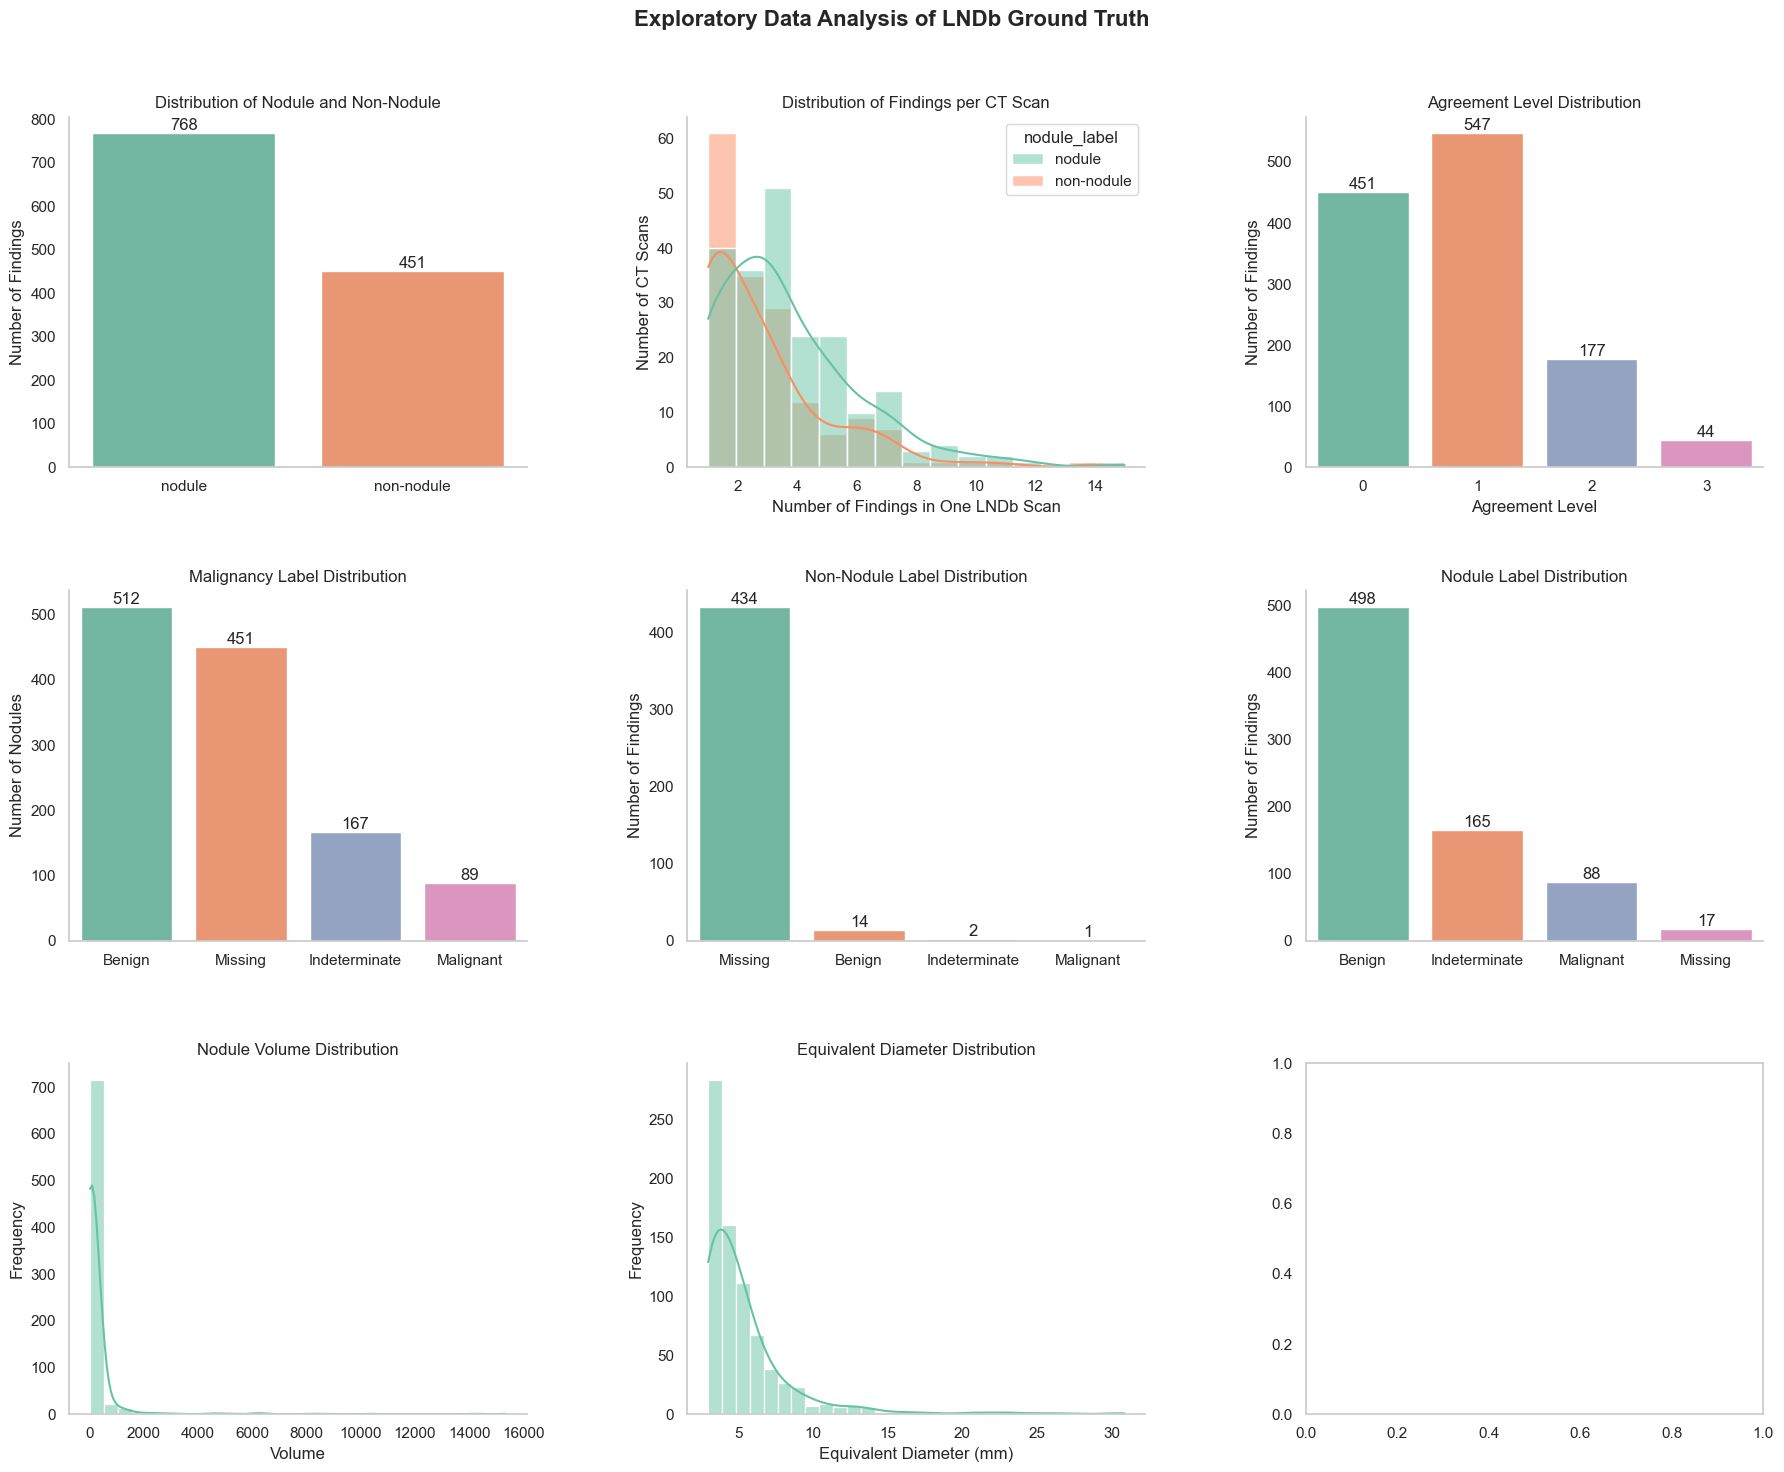

In [20]:
train_nodules_gt_enriched_df["nodule_label"] = (
    train_nodules_gt_enriched_df["nodule"].map({
        0: "non-nodule",
        1: "nodule"
    })
)

# Dashboard Layout
n_charts = 8
n_cols = 3
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows)
)

fig.suptitle(
    "Exploratory Data Analysis of LNDb Ground Truth",
    fontsize=16,
    fontweight="bold"
)

axes = axes.flatten()

# Distribution of Nodule and Non-Nodule
ax = axes[0]

sns.countplot(
    data=train_nodules_gt_enriched_df,
    x="nodule_label",
    hue="nodule_label",
    legend=False,
    order=["nodule", "non-nodule"],
    ax=ax
)

ax.set_title("Distribution of Nodule and Non-Nodule")
ax.set_xlabel("")
ax.set_ylabel("Number of Findings")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)

# Distribution of Findings per CT Scan
ax = axes[1]

finding_per_scan = (
    train_nodules_gt_enriched_df
    .groupby(["lndbid", "nodule_label"])
    .size()
    .reset_index(name="count")
)

sns.histplot(
    data=finding_per_scan,
    x="count",
    hue="nodule_label",
    multiple="layer",
    bins=15,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Findings per CT Scan")
ax.set_xlabel("Number of Findings in One LNDb Scan")
ax.set_ylabel("Number of CT Scans")

sns.despine(ax=ax)

# Agreement Level Distribution
ax = axes[2]

agr_counts = (
    train_nodules_gt_enriched_df["agrlevel"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=agr_counts.index.astype(str),
    y=agr_counts.values,
    hue=agr_counts.index.astype(str),
    ax=ax
)

ax.set_title("Agreement Level Distribution")
ax.set_xlabel("Agreement Level")
ax.set_ylabel("Number of Findings")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)

# Malignancy Label Distribution
ax = axes[3]

label_counts = (
    train_nodules_gt_enriched_df["label"]
    .fillna("Missing")
    .value_counts()
)

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    hue=label_counts.index,
    ax=ax
)

ax.set_title("Malignancy Label Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of Nodules")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)


# Label Distribution for Non-Nodule
ax = axes[4]

non_nodule_counts = (
    train_nodules_gt_enriched_df[
        train_nodules_gt_enriched_df["nodule"] == 0
    ]["label"]
    .fillna("Missing")
    .value_counts()
)

sns.barplot(
    x=non_nodule_counts.index,
    y=non_nodule_counts.values,
    hue=non_nodule_counts.index,
    ax=ax
)

ax.set_title("Non-Nodule Label Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of Findings")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)

# Label Distribution for Nodule
ax = axes[5]

nodule_counts = (
    train_nodules_gt_enriched_df[
        train_nodules_gt_enriched_df["nodule"] == 1
    ]["label"]
    .fillna("Missing")
    .value_counts()
)

sns.barplot(
    x=nodule_counts.index,
    y=nodule_counts.values,
    hue=nodule_counts.index,
    ax=ax
)

ax.set_title("Nodule Label Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of Findings")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)

# Nodule Volume Distribution
ax = axes[6]

sns.histplot(
    data=train_nodules_gt_enriched_df[
        train_nodules_gt_enriched_df["nodule"] == 1
    ],
    x="volume",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Nodule Volume Distribution")
ax.set_xlabel("Volume")
ax.set_ylabel("Frequency")

sns.despine(ax=ax)

# Equivalent Diameter Distribution
ax = axes[7]

sns.histplot(
    data=train_nodules_gt_enriched_df[
        (train_nodules_gt_enriched_df["nodule"] == 1)
        & (train_nodules_gt_enriched_df["diameq_rad"].notna())
    ],
    x="diameq_rad",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Equivalent Diameter Distribution")
ax.set_xlabel("Equivalent Diameter (mm)")
ax.set_ylabel("Frequency")

sns.despine(ax=ax)

# Final Layout
for ax in axes:
    ax.grid(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.subplots_adjust(
    wspace=0.35,
    hspace=0.35
)

plt.show()

# Data Selection

## Remove Non Nodule

In [21]:
# Remove Non-Nodule Findings
before = len(train_nodules_gt_enriched_df)

clean_df = train_nodules_gt_enriched_df[
    train_nodules_gt_enriched_df["nodule"] == 1
].copy()

after = len(clean_df)

print("Remove Non-Nodule Findings")
print(f"Total before filtering : {before:,}")
print(f"Total removed          : {before - after:,}")
print(f"Total after filtering  : {after:,}")

Remove Non-Nodule Findings
Total before filtering : 1,219
Total removed          : 451
Total after filtering  : 768


In [22]:
clean_df["label"].unique()

array(['Benign', 'Indeterminate', 'Malignant', nan], dtype=object)

In [23]:
clean_df

,lndbid,radid,radfindingid,findingid,x,y,z,agrlevel,nodule,volume,...,calcification,subtlety,internalstructure,sphericity,margin,lobulation,spiculation,texture,label,nodule_label
0,1,"1,2,3","1,1,1",1,-44.203451,-119.073242,-37.5,3,1,222.360697,...,4.666667,3.666667,1.0,2.666667,3.0,1.333333,2.333333,5.0,Benign,nodule
1,1,1,2,2,25.852539,-126.969727,-45.5,1,1,152.381031,...,6.000000,3.000000,1.0,2.000000,4.0,1.000000,1.000000,4.0,Benign,nodule
2,2,"1,2,3","1,1,3",1,88.895508,-123.867513,-129.5,3,1,378.042297,...,4.000000,5.000000,1.0,3.000000,5.0,1.000000,1.000000,5.0,Benign,nodule
3,2,"1,3","2,2",2,63.534180,-112.756836,-117.5,2,1,174.844563,...,4.000000,5.000000,1.0,4.500000,5.0,1.500000,1.000000,5.0,Benign,nodule
4,2,"1,3","3,5",3,-103.850586,-116.742188,-253.0,2,1,297.708309,...,6.000000,3.500000,1.0,4.500000,4.5,1.500000,1.000000,5.0,Benign,nodule
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1206,310,2,1,2,-100.263672,-224.498047,-142.5,1,1,14.137167,...,6.000000,4.000000,1.0,4.000000,4.0,1.000000,1.000000,4.0,Benign,nodule
1207,310,2,2,3,-121.220703,-181.138672,-193.5,1,1,15.666962,...,3.000000,3.000000,1.0,5.000000,5.0,1.000000,1.000000,5.0,Benign,nodule
1208,310,2,3,4,141.826172,-151.509766,-143.5,1,1,14.137167,...,6.000000,1.000000,1.0,5.000000,5.0,1.000000,1.000000,4.0,Benign,nodule
1209,310,2,4,5,125.205078,-127.662109,-57.5,1,1,14.137167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nodule


In [24]:
clean_df.shape

(768, 23)

## Remove Interdeminate

In [25]:
# Remove Indeterminate Nodules
before = len(clean_df)

clean_df = clean_df[
    clean_df["label"].isin(["Benign", "Malignant"])
].copy()

after = len(clean_df)

print("\nRemove Indeterminate Nodules")
print(f"Total before filtering : {before:,}")
print(f"Total removed          : {before - after:,}")
print(f"Total after filtering  : {after:,}")


Remove Indeterminate Nodules
Total before filtering : 768
Total removed          : 182
Total after filtering  : 586


In [26]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 586 entries, 0 to 1212
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lndbid             586 non-null    int64  
 1   radid              586 non-null    object 
 2   radfindingid       586 non-null    object 
 3   findingid          586 non-null    int64  
 4   x                  586 non-null    float64
 5   y                  586 non-null    float64
 6   z                  586 non-null    float64
 7   agrlevel           586 non-null    int64  
 8   nodule             586 non-null    int64  
 9   volume             586 non-null    float64
 10  text               586 non-null    float64
 11  diameq_rad         586 non-null    float64
 12  malignancy         586 non-null    float64
 13  calcification      586 non-null    float64
 14  subtlety           586 non-null    float64
 15  internalstructure  586 non-null    float64
 16  sphericity         586 non-nul

In [27]:
clean_df["label"].unique()

array(['Benign', 'Malignant'], dtype=object)

In [28]:
clean_df.to_csv(
    "../../dataset/_lndb/000_metadata/trainset_csv/trainNodules_gt_clean_v2.csv",
    index=False
)